In [1]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/nearest_neighbour.csv')
df1['condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/nearest_neighbour.csv')
df2["condition"] = np.where(df2["track_id"] == 0, "Starved (F-S)", "Fed (F-S)")

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/nearest_neighbour.csv')
df3['condition'] = 'Starved-Starved'

df = pd.concat([df1, df2, df3], ignore_index=True)  


order = [
    'Fed-Fed', 'Fed (F-S)', 'Starved (F-S)', 'Starved-Starved'
]

palette = {
    'Fed-Fed': '#4C72B0',
    'Starved (F-S)': '#F3D00E',
    'Fed (F-S)': '#0B5D2A',
    'Starved-Starved': '#C44E52',
}



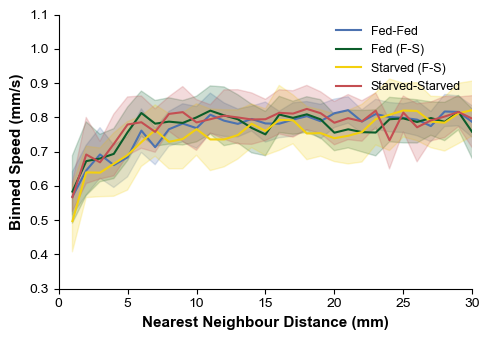

In [2]:
df_speed = df.copy()

bins = list(range(0, 90, 1))
df_speed['bin'] = pd.cut(df_speed['head_distance'], bins, include_lowest=True)
df_speed['bin_right'] = df_speed['bin'].apply(lambda x: x.right).astype(float)


speed_plot = (
    df_speed.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed']
      .mean()
)


fig, ax = plt.subplots(figsize=(5, 3.5))

sns.lineplot(
    data=speed_plot,
    x='bin_right',
    y='speed',
    hue='condition',
    hue_order=order,
    errorbar=('ci', 95),
    palette=palette,
    ax=ax,
)

ax.set_xlim(0, 30)
ax.set_ylim(0.3, 1.1)
ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Binned Speed (mm/s)', fontsize=11, fontweight='bold')
ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

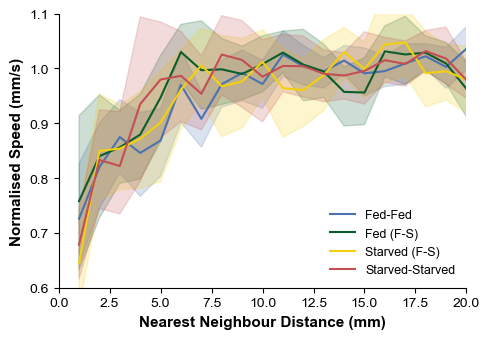

In [4]:

df_norm = df.copy()

bins = list(range(0, 90, 1))  # [0, 10, 20, ..., 100]
df_norm['bin'] = pd.cut(df_norm['head_distance'], bins, include_lowest=True) #body-body ; closest_node_distance ; head_distance
df_norm['bin_right'] = df_norm['bin'].apply(lambda x: x.right).astype(float)


baseline = (
    df_norm[(df_norm['bin_right'] >= 10) & (df_norm['bin_right'] < 20)]
      .groupby(['condition', 'filename'], as_index=False)['speed']
      .mean()
      .rename(columns={'speed': 'mean_speed_10_20'})
)

df_norm = df_norm.merge(baseline, on=['condition', 'filename'], how='left')
df_norm = df_norm.dropna(subset=['mean_speed_10_20']).copy()
df_norm['speed_norm'] = df_norm['speed'] / df_norm['mean_speed_10_20']


df_plot = (
    df_norm.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)


fig, ax = plt.subplots(figsize=(5, 3.5))

sns.lineplot(
    data=df_plot,
    x='bin_right',
    y='speed_norm',
    hue='condition',
    hue_order=order,
    errorbar=('ci', 95),
    palette=palette,
    ax=ax,
)

ax.set_ylim(0.6, 1.1)
ax.set_xlim(0, 20)
ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalised Speed (mm/s)', fontsize=11, fontweight='bold')
ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()